<a href="https://colab.research.google.com/github/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/blob/main/Notebooks/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK FROM SCRATCH**

**IMPORT LIBRARIES**

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

**DEFINE CLASS**

In [115]:
class NeuralNetwork():

  """Representation of a neural network"""

  def __init__(self, learning_rate:int, layers:list, epochs:int):

    """Initialize the neural network"""

    self.learning_rate = learning_rate
    self.layers = layers
    self.epochs = epochs
    self.count_layers =len(layers)

  def initialize_weights(self ,input_size:int):

    """Initialize the weights of the neural network with random numbers between 1 and 0"""

    self.weights = []
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      if current_layer == 0:
        shape=(layer_size, input_size)
      else:
        layer_before = current_layer-1
        layer_before_size = self.layers[layer_before]
        shape=(layer_size ,layer_before_size)
      self.weights.append(np.random.sample(shape))

  def initialize_biases(self):

    """Initialize the biases of the neural network with random numbers between 1 and 0"""

    self.biases=[]
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      shape=(layer_size,1)
      self.biases.append(np.zeros(shape))

  def get_relu_activation(self,z):

    """Get the sigmoud activation of the net input of a neural network"""
    return np.where(z > 0, z, 0)


  def get_softmax_activation(self,z):

    """Get the softmax activation of last layer of the neural network"""

    return np.exp(z)/  np.sum(np.exp(z))

  def get_layer_activations(self,sample_features):

    """Get the activation of the neurons of the neural network"""

    current_activations = sample_features
    layer_activations = []
    for current_layer in range(self.count_layers):
      net_input = (self.weights[current_layer] @ current_activations)+self.biases[current_layer]
      if(current_layer==self.count_layers-1):
        net_input_normalized = net_input-np.max(net_input)
        current_activations = self.get_softmax_activation(net_input_normalized)
      else:current_activations= self.get_relu_activation(net_input)
      layer_activations.append(current_activations)
    return layer_activations

  def backpropagation(self,layer_activations, sample,label):

    """Calculate the gradient of the weights and biases"""

    weights_gradients=[]
    biases_gradients=[]
    last_layer=self.count_layers-1
    first_layer=0
    for current_layer in range(last_layer,-1,-1):
      layer_activation= layer_activations[current_layer]
      if(current_layer == last_layer):
        label=label[:,None]
        layer_errors=layer_activation - label
      else:
        cost_derivative = np.transpose(self.weights[current_layer+1]) @ layer_errors
        activation_derivative =  np.where(layer_activation > 0, 1, 0)
        layer_errors=cost_derivative * activation_derivative
      if(current_layer==first_layer): input_layer= np.transpose(sample)
      else:input_layer= np.transpose(layer_activations[current_layer-1])
      weights_derivative = layer_errors @ input_layer
      biases_derivative=layer_errors
      weights_gradients.insert(0,weights_derivative)
      biases_gradients.insert(0,biases_derivative)

    return weights_gradients, biases_gradients


  def optimization(self,weights_gradients,biases_gradients):

    "update the weights and the biases of the neural network to minimize the cost using gradient descent"

    for current_layer in range(self.count_layers):
      self.weights[current_layer] += -1*self.learning_rate*weights_gradients[current_layer]
      self.biases[current_layer] += -1*self.learning_rate*biases_gradients[current_layer]

  def fit(self, samples,labels):

    """Train neural network and stores cost history"""

    count_samples = samples.shape[0]
    count_features= samples.shape[1]
    self.initialize_weights(count_features)
    self.initialize_biases()
    self.cost_history=[]
    with tqdm(total=self.epochs) as pbar:
      for i in range (self.epochs):
        cost = 0;
        for j in range (count_samples):
          sample = samples[j][:,None]
          label= labels[j]
          layer_activations=self.get_layer_activations(sample)
          prediction=layer_activations[-1]
          cost+=-np.log(prediction[label==1])[0][0]
          weights_gradients, biases_gradients= self.backpropagation(layer_activations,sample,label)
          self.optimization(weights_gradients,biases_gradients)
        cost/=count_samples
        pbar.update(1)
        self.cost_history.append(cost)

  def plot_cost_history(self):

    """plot the value of the cost function for each epoch on the training process"""

    plt.plot(range(1,len(self.cost_history)+1),self.cost_history)
    plt.xlabel("epoch")
    plt.ylabel("cost")
    plt.title("history of cost function")



  def predict(self,sample):

    """Returns the activation of the last layout for a sample"""

    return self.get_layer_activations(sample)[-1]







**GRAPH (COST VS NEURON'S PROBABILITY OF CHOOSE THE CORRECT CLASS )**

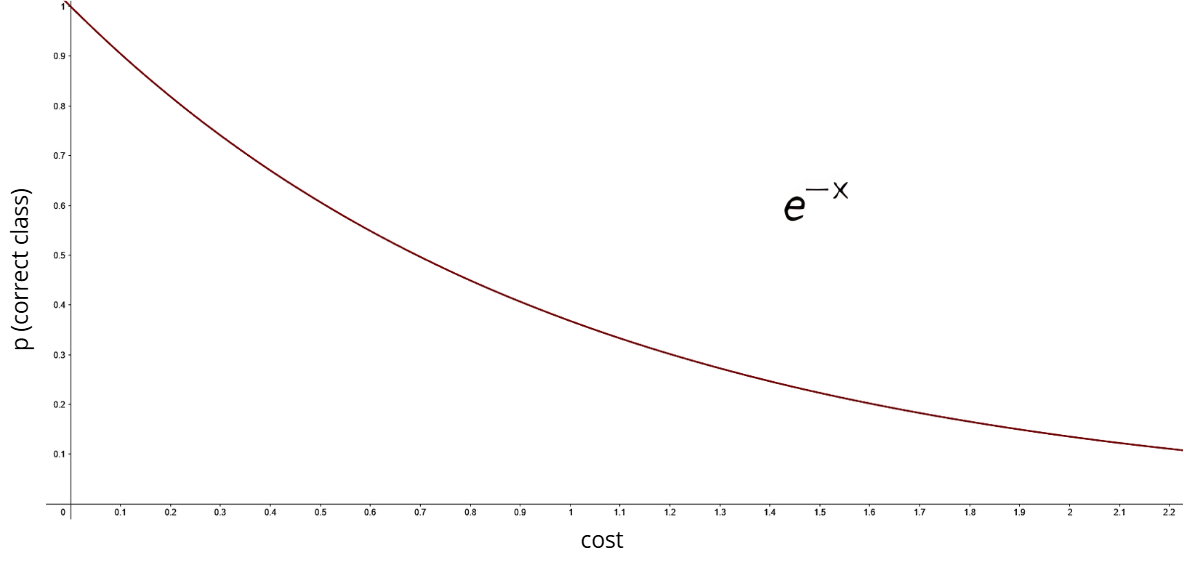

# **TEST NEURAL NETWORK**

**UNIT TESTS**

In [108]:
#Test weights' initialization

model= NeuralNetwork(0.1,[110,3],5)
model.initialize_weights(110)
print(model.weights)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_weights(3)
print(model.weights)

[array([[0.61346192, 0.31941777, 0.85344487, ..., 0.91421467, 0.12681775,
        0.88421511],
       [0.5293107 , 0.68025814, 0.86221525, ..., 0.14085687, 0.78077075,
        0.28066327],
       [0.37440143, 0.65664308, 0.50838669, ..., 0.68183651, 0.05237875,
        0.15146491],
       ...,
       [0.99031641, 0.53980746, 0.88367821, ..., 0.8306044 , 0.96309049,
        0.21710219],
       [0.04015771, 0.4350228 , 0.51169248, ..., 0.07586383, 0.95934062,
        0.21337371],
       [0.83844076, 0.3019354 , 0.80450031, ..., 0.53357334, 0.63539229,
        0.73567925]]), array([[0.17767226, 0.71924489, 0.48559205, 0.46817465, 0.20531362,
        0.85823014, 0.78577802, 0.94733478, 0.71779654, 0.73064756,
        0.13322562, 0.56833203, 0.27330822, 0.3846148 , 0.35121191,
        0.18157298, 0.63881192, 0.24934425, 0.73252678, 0.37513447,
        0.13340129, 0.32144769, 0.61381702, 0.50848802, 0.03998154,
        0.86807354, 0.19584175, 0.12983347, 0.90440179, 0.6764433 ,
        0.035

In [ ]:
#Test biases' initialization

model= NeuralNetwork(0.1,[2,2,1,2,1,1],5)
model.initialize_biases()
print(model.biases)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_biases()
print(model.biases)

[array([[0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.]])]
[array([[0.]]), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]])]


In [73]:
#Test neuron' activations

model= NeuralNetwork(0.1,[110,3],5)
model.initialize_weights(110)
model.initialize_biases()
arr = np.zeros(110, dtype=int)
arr[10] = 1
arr[50] = 1
sample=np.array(arr)[:,None]
print(model.get_layer_activations(sample)[-1])

[[0.23328143]
 [0.55208346]
 [0.21463511]]


# **EXPERIMENTS WITH NEURAL NETWORK**

**CHARGE SOCCER DATASET**

In [4]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
df=pd.read_csv('historical_european_soccer_matches.csv')

--2026-08-14 17:19:29--  https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2994531 (2.9M) [text/plain]
Saving to: ‘historical_european_soccer_matches.csv’

historical_european 100%[===================>]   2.86M  --.-KB/s    in 0.05s   

2026-08-14 17:19:30 (61.4 MB/s) - ‘historical_european_soccer_matches.csv’ saved [2994531/2994531]



**TRAIN NEURAL NETWORK**

100%|██████████| 5000/5000 [2:23:27<00:00,  1.72s/it]


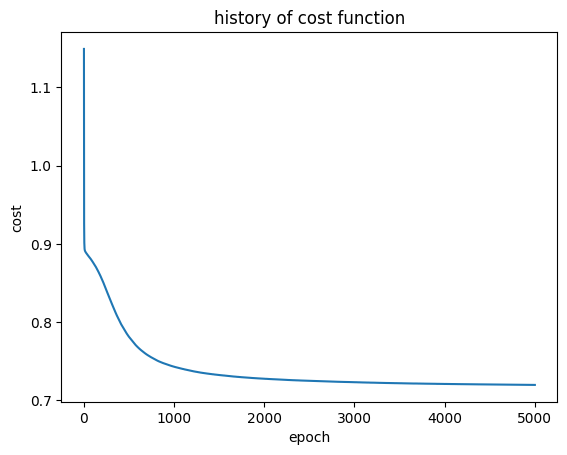

In [120]:
samples= df.iloc[:,:-3].values
labels= df.iloc[:,-3:].values
model= NeuralNetwork(0.001,[110,3],5000)
model.fit(samples,labels)
model.plot_cost_history()


**ID OF TEAMS**

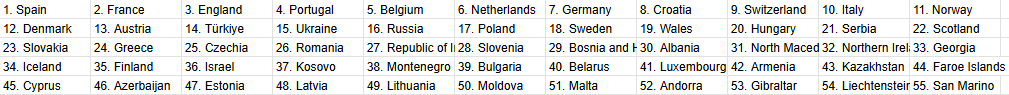

In [ ]:
def arg_max_prediction(predictions):
  if(np.max(predictions)==predictions[0][0]):
    print("The home team wins")
  elif(np.max(predictions)==predictions[1][0]):
    print("The away team wins")
  elif(np.max(predictions)==predictions[2][0]):
    print("The teams draw")



while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=1
  sample=sample[:,None]
  arg_max_prediction(model.predict(sample))

type a home team by its id : 1
type a away team by its id : 12
The home team wins
type a home team by its id : 3
type a away team by its id : 1
The away team wins
type a home team by its id : 1
type a away team by its id : 55
The home team wins
type a home team by its id : 1
type a away team by its id : 13
The home team wins
type a home team by its id : 7
type a away team by its id : 5
The home team wins
type a home team by its id : 5
type a away team by its id : 7
The away team wins
type a home team by its id : 1
type a away team by its id : 10
The home team wins
type a home team by its id : 10
type a away team by its id : 1
The teams draw
type a home team by its id : 1
type a away team by its id : 7
The teams draw
type a home team by its id : 7
type a away team by its id : 1
The away team wins
type a home team by its id : 7
type a away team by its id : 10
The teams draw
type a home team by its id : 10
type a away team by its id : 7
The teams draw
type a home team by its id : 4
type a